# Modelos de regressão múltipla

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>
Copyright: Creative Commons

<hr>

Para o caso multivariado, vimos que a estimação dos coeficientes pelo método dos mínimos quadrados resulta na relação:
$$
\beta = (\text{X}^T \text{X})^{-1} \text{X}^T \text{y}
$$
onde
$$
\text{X} = \begin{pmatrix}
1 & x_{11} &x_{12} &\ldots &x_{1d} \\
1 & x_{21} &x_{22} &\ldots &x_{2d} \\
\ldots & \ldots &\ldots &\ldots &\ldots \\
1 & x_{n1} &x_{n2} &\ldots &x_{nd} \\
\end{pmatrix}
$$

Vamos considerar dados reais e a biblioteca scikit-learn. Inicialmente, carregamos os dados.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# le os dados
#data = pd.read_csv('data/BostonHousing.csv', header=(0))
data = pd.read_csv('data/Advertising.csv', header=(0), index_col=[0])
# valor a ser predito
ylabel = data.columns[-1]
print("Número de linhas e colunas:", data.shape)
data.head(10)

Número de linhas e colunas: (200, 4)


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


Transformos os dados para o formato numpy para facilitar o acesso.

In [18]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Selecionamos os conjuntos de teste e treinamento, sendo que $p$% dos dados serão usados como teste e (1-p)%, como treinamento.

In [19]:
from sklearn.model_selection import train_test_split
# divide o conjunto em treinamento e teste
p = 0.2 # fracao e elementos no conjnto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

O ajuste dos coeficientes da regressão linear é feito usando apenas o conjunto de treinamento.

In [20]:
from sklearn.linear_model import LinearRegression

# modelo de regressão linear múltipla
lm = LinearRegression()
lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)

Notem que como temos várias variáveis, não é possível mostrar os resultados em mais de três dimensões. Nesse caso, uma maneira de visualizar a precisão na predição é graficar os valores reais versus as predições, como mostramos abaixo.

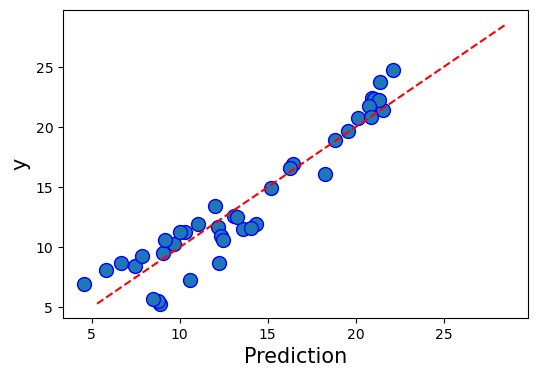

In [21]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6,4))
l = plt.plot(y_pred, y_test, 'bo')
plt.setp(l, markersize=10)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction", fontsize=15)

# mostra os valores preditos e originais
xl = np.arange(min(y_test), 1.2*max(y_test),(max(y_test)-min(y_test))/10)
yl = xl
plt.plot(xl, yl, 'r--')

plt.show(True)
# salva a figura em um arquivo
fig.savefig('regression-LR.jpg')

Quanto mais próximo da reta em vermelho, melhor será a predição, pois essa reta representa o caso em que $\hat{y} = y$.

Para quantificarmos o ajuste, calculamos o coeficiente R2.

In [22]:
from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

R2: 0.899438024100912


Usando a biblioteca OLS:

In [23]:
import statsmodels.api as sm

model = sm.OLS(y_train,X_train)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.982
Model:                            OLS   Adj. R-squared (uncentered):              0.982
Method:                 Least Squares   F-statistic:                              2935.
Date:                Thu, 09 Jul 2026   Prob (F-statistic):                   1.28e-137
Time:                        12:11:09   Log-Likelihood:                         -336.65
No. Observations:                 160   AIC:                                      679.3
Df Residuals:                     157   BIC:                                      688.5
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Fazendo a predição no conjunto de teste:

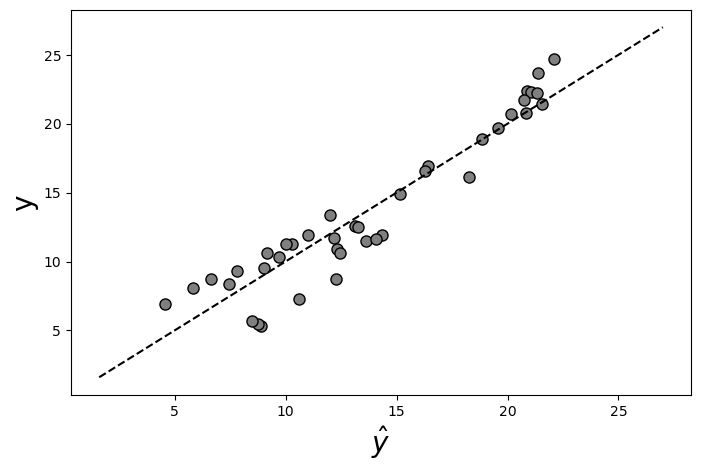

In [24]:
import matplotlib.pyplot as plt
import numpy as np

yhat = results.predict(X_test)

# mostra os resultados
plt.figure(figsize=(8,5))
l = plt.plot(y_pred, y_test, 'o', color='gray', markersize=8, 
         markerfacecolor='gray', 
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)], 
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=20)
plt.xlabel(r"$\hat{y}$", fontsize=20)
plt.savefig('regression-concrete.svg')
plt.show(True)

## Regressão polinomial

De maneira similar à regressão multivariada, podemos realizar a  regressão polinomial. Nesse caso, o objetivo é ajustar um polinômio ao conjunto de dados.  Por exemplo,  o modelo pode ser dado por:
$$
Y = \theta_0 + \theta_1 x + \theta_2 x^2 + \ldots + \theta_k x^k = \sum_{j=0}^k \theta_j x^j.
$$
Notem que se fizermos $X_j = X^j$ nessa equação, obtemos um modelo similar ao apresentado anteriormente:
$$
Y_j=\theta_0 + \theta_1 x_{1j} + \theta_2 x_{2j} + \ldots + + \theta_k x_{kj} + \epsilon_j, \quad j=1,2,\ldots, n,
$$

Notem que o modelo não precisa ter termos lineares em X, mas apenas nos parâmetros. Por exemplo, modelo abaixo ainda é linear nos parâmetros: $$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon$$

Vamos considerar um exemplo.

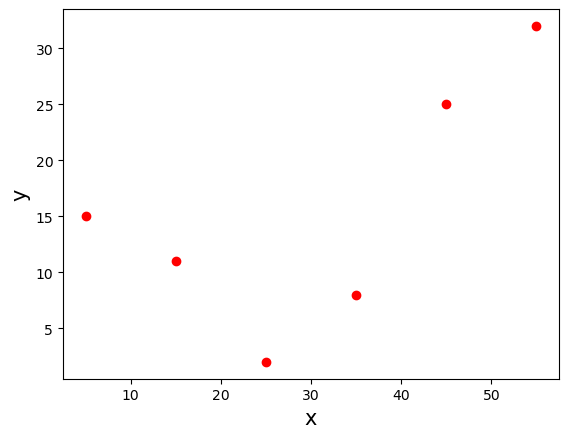

In [25]:
import numpy as np
from sklearn.linear_model import LinearRegression

x = np.array([5, 15, 25, 35, 45, 55])
y = np.array([15, 11, 2, 8, 25, 32])
plt.plot(x,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

In [26]:
print('x:',  x)
print('y:', y)

x: [ 5 15 25 35 45 55]
y: [15 11  2  8 25 32]


Geramos os dados quadráticos inserindo mais uma coluna.

In [27]:
from sklearn.preprocessing import PolynomialFeatures

# define a transformação nos dados
transformer = PolynomialFeatures(degree=2, include_bias=False)
x = x.reshape((-1, 1))
transformer.fit(x)
print('Dados originais:\n', x)

# transforma os dados incluindo uma nova coluna com valores quadráticos
x_ = transformer.transform(x)
print('Novos dados:\n', x_)

Dados originais:
 [[ 5]
 [15]
 [25]
 [35]
 [45]
 [55]]
Novos dados:
 [[   5.   25.]
 [  15.  225.]
 [  25.  625.]
 [  35. 1225.]
 [  45. 2025.]
 [  55. 3025.]]


O modelo será dado por: $$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon$$

Vamos aplicar a regressão linear:

In [28]:
model = LinearRegression().fit(x_, y)
y_pred = model.predict(x_)

Mostrando os valores preditos ($\hat{y}$) e os originais ($y$):

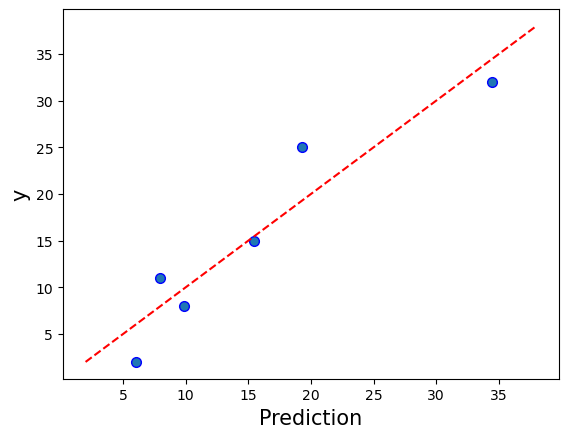

In [29]:
import matplotlib.pyplot as plt

fig = plt.figure()
l = plt.plot(y_pred, y, 'bo')
plt.setp(l, markersize=7)
plt.setp(l, markerfacecolor='C0')

plt.ylabel("y", fontsize=15)
plt.xlabel("Prediction", fontsize=15)

# mostra a reta diagonal, que representa a predição perfeita
xl = np.arange(min(y), 1.2*max(y),(max(y)-min(y))/10)
yl = xl
plt.plot(xl, yl, 'r--')

plt.show(True)

Mostrando os valores no gráfico original:

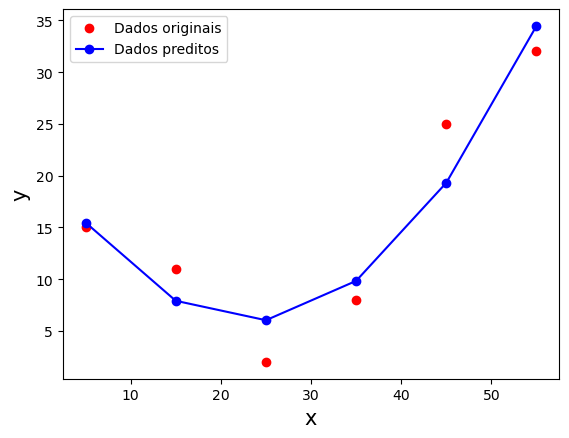

In [30]:
plt.plot(x,y, 'ro', label='Dados originais')
plt.plot(x,y_pred, 'bo-', label = 'Dados preditos')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)
plt.legend()
plt.show(True)

O coeficiente R2:

In [31]:
from sklearn.metrics import r2_score
R2 = r2_score(y, y_pred)
print('R2:', R2)

R2: 0.8908516262498564


Portanto, para ajustar um modelo com variáveis não lineares, basta gerarmos um novo conjunto de dados inserindo novas colunas aos dados originais e realizar o procedimento de regressão multivariada. Cada coluna inserida contém os dados originais elevados a uma potência definida pelos termos do modelo.

## Inferência sobre os parâmetros


Vamos gerar os dados e usar a biblioteca ols para realizar a inferência (https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLS.html)

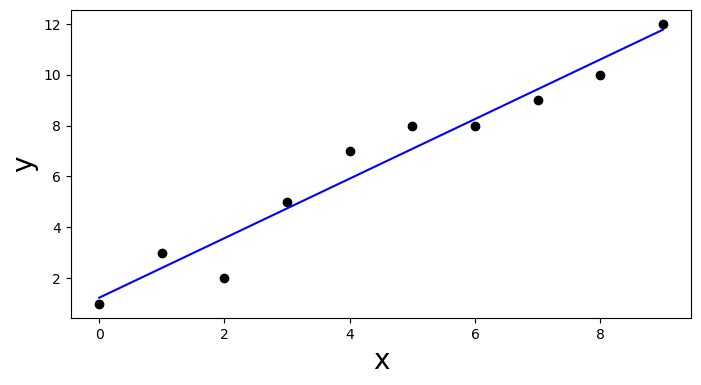

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.953
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     160.6
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.41e-06
Time:                        12:11:09   Log-Likelihood:                -11.312
No. Observations:                  10   AIC:                             26.62
Df Residuals:                       8   BIC:                             27.23
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2364      0.493      2.509      0.0

In [32]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.formula.api import ols

# dados
x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) 
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])
data = pd.DataFrame({'x': x, 'y': y})

# ajusta o modelo de regressão linear
x = x.reshape(-1, 1)
reg = LinearRegression().fit(x, y)
y_predicted = reg.predict(x)

# mostra os resultados
plt.figure(figsize=(8,4))
plt.plot(x, y, 'o', color='black');
plt.plot(x,y_predicted,color='blue')
plt.xlabel('x', fontsize = 20) 
plt.ylabel('y', fontsize = 20) 
plt.show(True) 

# sumários estatístico com OLS
model = ols("y ~ x", data).fit()
print(model.summary())

O intervalo de confiança de 95%:

In [33]:
print('IC: ', model.conf_int(alpha=0.05, cols=None))

IC:                    0         1
Intercept  0.099934  2.372793
x          0.956824  1.382570


Vamos considerar um caso em que o modelo não se aplica.

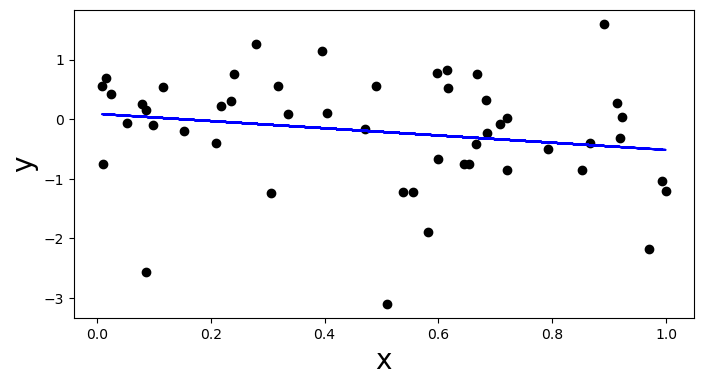

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.913
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.173
Time:                        12:11:09   Log-Likelihood:                -67.131
No. Observations:                  50   AIC:                             138.3
Df Residuals:                      48   BIC:                             142.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0914      0.253      0.361      0.7

In [34]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

# dados
n = 50
x = np.random.uniform(0, 1,n)
y = np.random.normal(0,1, n)
data = pd.DataFrame({'x': x, 'y': y})

# ajusta o modelo de regressão linear
x = x.reshape(-1, 1)
reg = LinearRegression().fit(x, y)
y_predicted = reg.predict(x)

# Mostra os resultados
plt.figure(figsize=(8,4))
plt.plot(x, y, 'o', color='black');
plt.plot(x,y_predicted,color='blue')
plt.xlabel('x', fontsize = 20) 
plt.ylabel('y', fontsize = 20) 
plt.savefig('regress-random.svg')
plt.show(True) 

# sumários estatístico com OLS
model = ols("y ~ x", data).fit()
print(model.summary())

No caso multivariado:

In [35]:
from statsmodels.formula.api import ols
import pandas as pd
import numpy as np
np.random.seed(10)

n = 500 # número de observações
# gera os dados
x1 = np.random.uniform(0,10, (n, 1));
x2 = np.random.uniform(0,10, (n, 1));
x3 = np.random.uniform(1,10, (n, 1));
e = np.random.normal(0,5, (n, 1))
y = 5 + 2*x1 + 3*x2 + e

X = np.hstack((x1,x2,x3,y))
data = pd.DataFrame(X, columns = ['x1', 'x2','x3','y'])

# sumários estatístico com o OLS
model = ols(formula='y ~ x1 + x2 + x3', data = data).fit()
print(model.summary())
print('Parâmetros:\n', model.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     916.3
Date:                Thu, 09 Jul 2026   Prob (F-statistic):          8.25e-202
Time:                        12:11:09   Log-Likelihood:                -1507.3
No. Observations:                 500   AIC:                             3023.
Df Residuals:                     496   BIC:                             3039.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.2219      0.709      5.953      0.0

### Inferência sobre o modelo em um conjunto de dados

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
np.random.seed(101)

# le os dados
#data = pd.read_csv('data/BostonHousing.csv', header=(0))
data = pd.read_csv('data/Advertising.csv', header=(0), index_col=[0])
# valor a ser predito
ylabel = data.columns[-1]
print("Número de linhas e colunas:", data.shape)
data.head(10)

# monta o modelo: y ~ x1 + x2 + ...
model_string =  data.columns[0]
features = data.columns[1:-1]
for s in features:
    model_string = model_string + '+' + s
model_string = data.columns[-1] + '~' + model_string
print('Modelo as ser ajustado: ', model_string)

model = ols(model_string, data).fit()
print(model.summary())

Número de linhas e colunas: (200, 4)
Modelo as ser ajustado:  sales~TV+radio+newspaper
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 09 Jul 2026   Prob (F-statistic):           1.58e-96
Time:                        12:11:09   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------

## Diagnóstico

Após o ajuste do modelo, é importante realizar um diagnóstico com relação ao que foi assumido na sua elaboração. Quando realizamos a inferência, vimos que  assumimos que os erros são normalmente distribuídos. Desse modo, é esperando que os resíduos sejam normalmente distribuídos com média igual a zero. Verificamos essa propriedade no histograma a seguir.

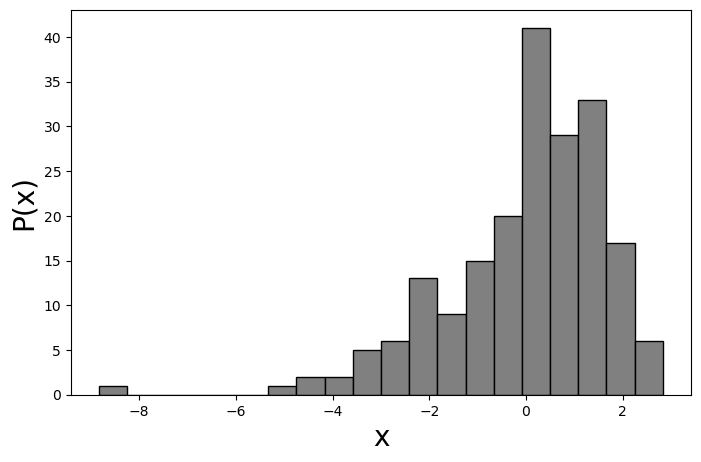

In [37]:
plt.figure(figsize=(8,5))
residuals = model.resid

plt.hist(residuals, bins=20, color = 'gray', histtype='bar', ec='black')  
plt.xlabel('x', fontsize = 20)
plt.ylabel('P(x)',fontsize = 20)
plt.show(True)

Também podemos construir um gráfico quantil-quantil para verificar se a distribuição dos resíduos se aproxima de uma normal.

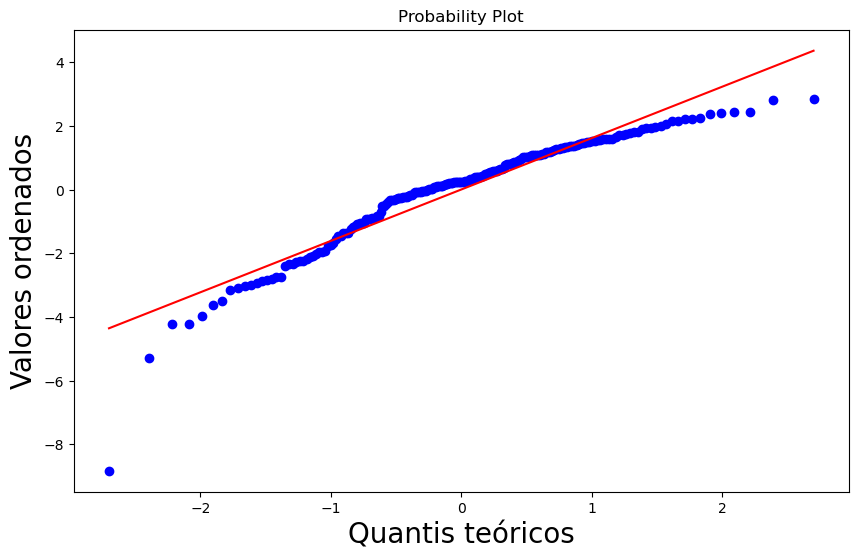

In [38]:
import numpy as np 
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
stats.probplot(np.sort(residuals), dist="norm",plot=plt)

plt.xlabel('Quantis teóricos', fontsize = 20)
plt.ylabel('Valores ordenados',fontsize = 20)
plt.savefig('QQ.svg')
plt.show(True)

Finalmente, podemos mostrar os resíduos em função dos valores preditos. Espera-se que os resíduos sejam aleatoriamente distribuídos em torno de zero.


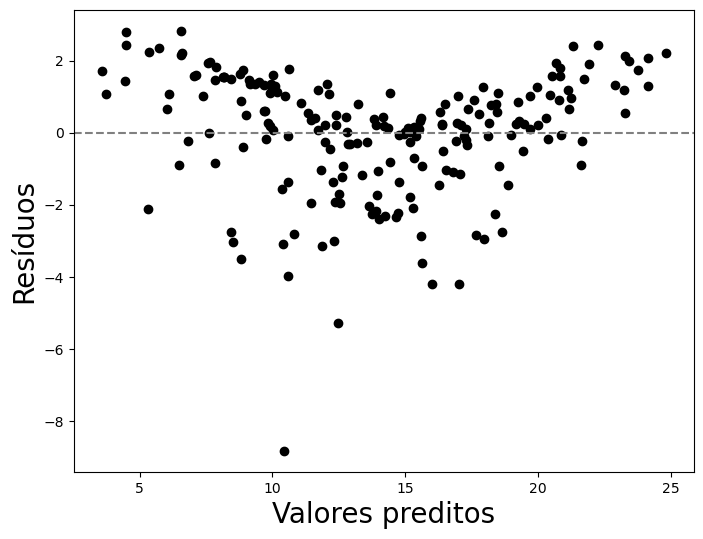

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(model.fittedvalues, residuals,color='black')
plt.axhline(y = 0, color = 'gray', linestyle = '--')
plt.xlabel('Valores preditos',fontsize = 20)
plt.ylabel('Resíduos', fontsize = 20)
plt.savefig('residuos-diagnosis.svg')
plt.show(True)

## Exercícios de fixação

1 - Para os dados gerados pelo código abaixo, ajuste um modelo de regressão polinomial considerando um polinômio de grau 3 e 5. Qual oferece o melhor ajuste em termos do coeficiente R2?

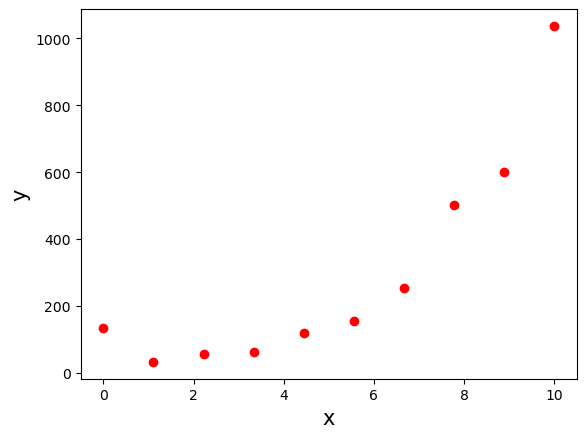

In [40]:
import numpy as np
from sklearn.linear_model import LinearRegression

N = 10
x = np.linspace(0,10,N)
y = x**3 + np.random.normal(0,50, N)
plt.plot(x,y, 'ro')
plt.ylabel("y", fontsize=15)
plt.xlabel("x", fontsize=15)

plt.show(True)

2 - Ajuste um modelo e realize a inferência para a base de casas de Boston. Faça o diagnóstico e verifique se o modelo é adequado.